In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [8]:
data = pd.read_csv("ab_data.csv")

In [9]:
data.head(10)

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1
5,936923,2017-01-10 15:20:49.083499,control,old_page,0
6,679687,2017-01-19 03:26:46.940749,treatment,new_page,1
7,719014,2017-01-17 01:48:29.539573,control,old_page,0
8,817355,2017-01-04 17:58:08.979471,treatment,new_page,1
9,839785,2017-01-15 18:11:06.610965,treatment,new_page,1


In [10]:
data.shape

(294478, 5)

In [11]:
countries = pd.read_csv("countries.csv")
countries

,user_id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK
...,...,...
290579,653118,US
290580,878226,UK
290581,799368,UK
290582,655535,CA


In [16]:
countries.groupby(["country"]).count()

,user_id
country,
CA,14499
UK,72466
US,203619


In [86]:
data = pd.merge(
    data,
    countries,
    on='user_id',
    how='inner'
)

In [18]:
#checking if there is any mismatch in group and landing page
#as Control group user should see Old page and Treatment group user should see New page

In [24]:
mismatch = (
    ((data['group'] == 'control') & (data['landing_page'] != 'old_page')) |
    ((data['group'] == 'treatment') & (data['landing_page'] != 'new_page'))
)

mismatch.sum()

np.int64(3893)

In [25]:
data = data[~mismatch]

In [27]:
data.shape

(290585, 5)

In [33]:
data = data.sort_values('timestamp')

In [34]:
data = data.drop_duplicates(
    subset='user_id',
    keep='first')

In [36]:
#checking if still any duplicate user id's are present
data['user_id'].duplicated().sum()

np.int64(0)

In [53]:
# Counting users in each group
group_counts = data['group'].value_counts()

print(group_counts)

group
treatment    145310
control      145274
Name: count, dtype: int64


<Figure size 800x500 with 0 Axes>

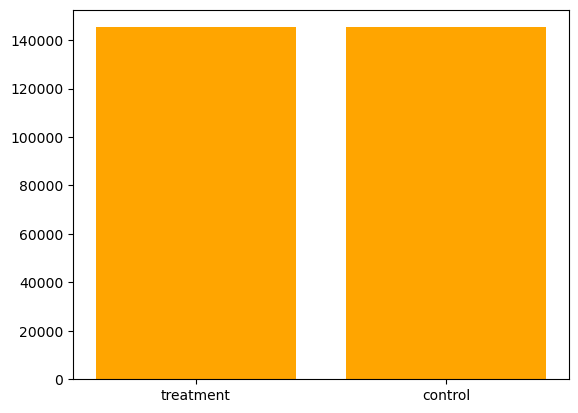

<Figure size 800x500 with 0 Axes>

In [64]:
plt.bar(
    group_counts.index,
    group_counts.values, color = 'orange',
)
plt.figure(figsize=(8, 5))

In [65]:
#Separating the two groups
control = data[data['group'] == 'control']['converted']
treatment = data[data['group'] == 'treatment']['converted']

In [66]:
control_rate = control.mean()
treatment_rate = treatment.mean()

print("Control conversion rate:", control_rate)
print("Treatment conversion rate:", treatment_rate)

Control conversion rate: 0.1203863045004612
Treatment conversion rate: 0.11880806551510564


In [75]:
from scipy.stats import ttest_ind

In [78]:
#TEST-1: performing Welch's t-test
t_stat, p_value = stats.ttest_ind(
    treatment,
    control,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)
alpha = 0.05 #level of significance

t-statistic: -1.3109226374655925
p-value: 0.18988493791578304


In [79]:
if p_value < alpha:
    print("Reject H0: There is a significant difference in conversion rates.")
else:
    print("Fail to reject H0: There is no statistically significant difference in conversion rates.")

Fail to reject H0: There is no statistically significant difference in conversion rates.


In [80]:
#TEST-2: Chi-square Test of Independence
contingency_table = pd.crosstab(
    data['group'],
    data['converted']
)

print(contingency_table)

converted       0      1
group                   
control    127785  17489
treatment  128046  17264


In [81]:
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 1.7035660051885058
p-value: 0.19182228096235662
Degrees of freedom: 1


In [83]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Group and conversion are significantly related.")
else:
    print("Fail to reject H0: Group and conversion are independent.")

Fail to reject H0: Group and conversion are independent.


In [91]:
#Test-3: One-way ANOVA by Country
country_conversion = data.groupby('country')['converted'].mean()

print("in percentage: ")
print((country_conversion * 100).round(2))

in percentage: 
country
CA    11.53
UK    12.06
US    11.95
Name: converted, dtype: float64


In [92]:
us = data[data['country'] == 'US']['converted']
uk = data[data['country'] == 'UK']['converted']
ca = data[data['country'] == 'CA']['converted']

In [93]:
f_stat, p_value = stats.f_oneway(
    us,
    uk,
    ca
)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 1.6052863959236205
p-value: 0.20083381020116486


In [94]:
if p_value < 0.05:
    print("Reject H0: At least one country has a significantly different conversion rate.")
else:
    print("Fail to reject H0: No significant difference in conversion rates across countries.")

Fail to reject H0: No significant difference in conversion rates across countries.


CONCLUSION: Based on rigorous statistical testing across three independent methods, there is no evidence that
the new pricing page improves conversion over the existing page, either overall or within any
individual country.